# Анализ пользовательского поведения и результатов A/A/B-теста в мобильном приложении

### Описание проекта

В ходе исследования проводится анализ поведения пользователей мобильного приложения по продаже продуктов питания.

Компания заинтересована в повышении эффективности пользовательского пути внутри приложения и оценивает влияние изменений интерфейса на поведение пользователей. Для этого необходимо изучить воронку событий, определить этапы с наибольшим оттоком пользователей и проанализировать результаты A/A/B-эксперимента, связанного с изменением шрифта в приложении.

### Цель исследования

Изучить пользовательскую воронку, определить основные точки потери пользователей и оценить влияние изменения шрифта на ключевые пользовательские действия.

Для анализа используются данные о действиях пользователей в мобильном приложении:

* информация о событиях, совершаемых пользователями;
* данные об участии пользователей в экспериментальных группах;
* временные метки всех действий пользователей.

В рамках исследования анализируются:

* структура и качество исходных данных;
* активность пользователей в приложении;
* воронка событий и конверсия между её этапами;
* доля пользователей, доходящих до покупки;
* корректность распределения пользователей между экспериментальными группами;
* результаты A/A-теста;
* результаты A/B-теста и влияние изменения шрифта на поведение пользователей.

# Общая информация

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np
import math as mth
import warnings
warnings.filterwarnings('ignore')

In [43]:
logs = pd.read_csv('logs_exp.csv', sep='\t')
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


# Предобработка данных

In [44]:
new_col_names = ['event_name', 'user_id', 'event_timestamp', 'exp_id']

logs.columns = new_col_names
logs.columns

Index(['event_name', 'user_id', 'event_timestamp', 'exp_id'], dtype='str')

In [45]:
logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   event_name       244126 non-null  str  
 1   user_id          244126 non-null  int64
 2   event_timestamp  244126 non-null  int64
 3   exp_id           244126 non-null  int64
dtypes: int64(3), str(1)
memory usage: 7.5 MB


In [46]:
logs['event_timestamp'] = pd.to_datetime(logs['event_timestamp'], unit='s')
logs['event_timestamp']

0        2019-07-25 04:43:36
1        2019-07-25 11:11:42
2        2019-07-25 11:28:47
3        2019-07-25 11:28:47
4        2019-07-25 11:48:42
                 ...        
244121   2019-08-07 21:12:25
244122   2019-08-07 21:13:59
244123   2019-08-07 21:14:43
244124   2019-08-07 21:14:58
244125   2019-08-07 21:15:17
Name: event_timestamp, Length: 244126, dtype: datetime64[s]

In [47]:
logs['event_date'] = logs['event_timestamp'].dt.date
logs['event_date']

0         2019-07-25
1         2019-07-25
2         2019-07-25
3         2019-07-25
4         2019-07-25
             ...    
244121    2019-08-07
244122    2019-08-07
244123    2019-08-07
244124    2019-08-07
244125    2019-08-07
Name: event_date, Length: 244126, dtype: object

In [48]:
logs.duplicated().sum()

np.int64(413)

In [49]:
logs[logs.duplicated(keep=False)]

,event_name,user_id,event_timestamp,exp_id,event_date
452,MainScreenAppear,5613408041324010552,2019-07-30 08:19:44,248,2019-07-30
453,MainScreenAppear,5613408041324010552,2019-07-30 08:19:44,248,2019-07-30
2348,CartScreenAppear,1694940645335807244,2019-07-31 21:51:39,248,2019-07-31
2350,CartScreenAppear,1694940645335807244,2019-07-31 21:51:39,248,2019-07-31
3572,MainScreenAppear,434103746454591587,2019-08-01 02:59:37,248,2019-08-01
...,...,...,...,...,...
242359,PaymentScreenSuccessful,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242360,PaymentScreenSuccessful,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242362,CartScreenAppear,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242634,MainScreenAppear,4097782667445790512,2019-08-07 19:36:58,246,2019-08-07


In [50]:
logs = logs.drop_duplicates()
logs

,event_name,user_id,event_timestamp,exp_id,event_date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
...,...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


In [51]:
logs['exp_id'].unique()

array([246, 248, 247])

В данных представлены три экспериментальные группы:

- 246 и 247 — контрольные группы;
- 248 — экспериментальная группа.

Пропуски в данных отсутствуют. Типы данных соответствуют содержанию столбцов после преобразования времени в формат datetime. Дополнительная обработка данных не требуется.

# Исследовательский анализ данных

In [52]:
print('Всего событий в логе:', len(logs))
print('Уникальные события:', list(logs['event_name'].unique()))
print('Количество типов событий:', logs['event_name'].nunique())

Всего событий в логе: 243713
Уникальные события: ['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear', 'OffersScreenAppear', 'Tutorial']
Количество типов событий: 5


В журнале содержится 243 713 событий (после удаления дубликатов). Это обеспечивает достаточный объём данных для анализа поведения пользователей и проведения статистических тестов.

In [53]:
print('Всего пользователей:', logs['user_id'].nunique())

Всего пользователей: 7551


В исследовании участвуют 7 551 уникальный пользователь. Такой размер выборки позволяет проводить сравнение экспериментальных групп с достаточной статистической мощностью.

In [54]:
print('Событий в среднем на пользователя:', round(logs.shape[0] / logs['user_id'].nunique()))

Событий в среднем на пользователя: 32


В среднем на одного пользователя приходится около 32 событий. Это говорит о том, что пользователи совершают в приложении несколько действий за одну сессию и могут многократно возвращаться к одним и тем же экранам.

In [55]:
logs['event_date'].min(), logs['event_date'].max()

(datetime.date(2019, 7, 25), datetime.date(2019, 8, 7))

В исходных данных представлены события за период с 25 июля по 7 августа 2019 года.

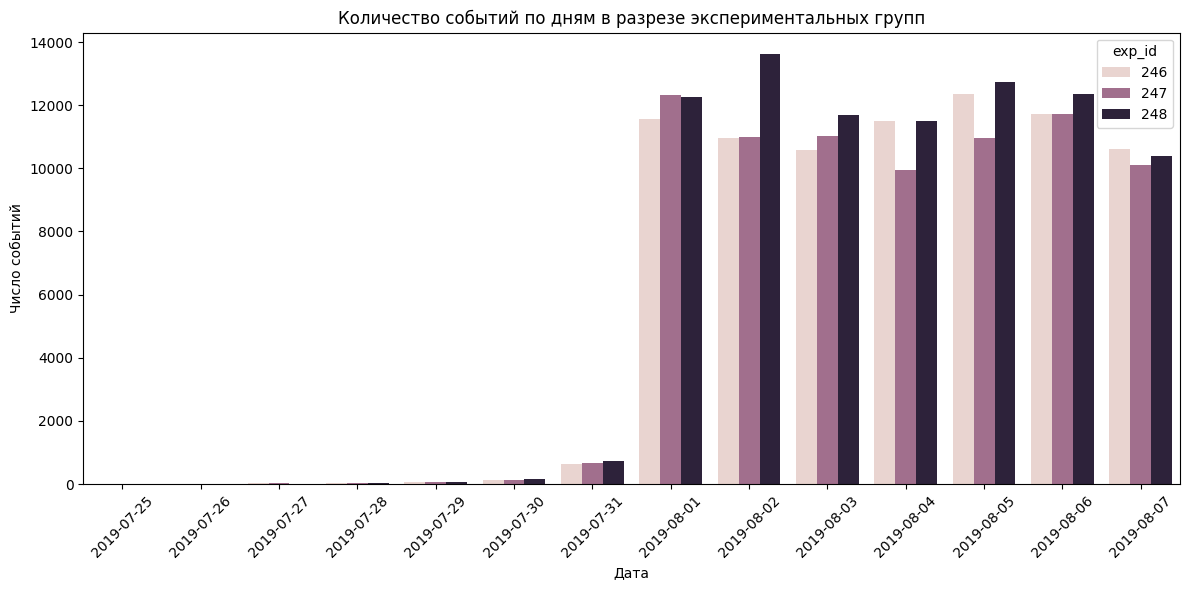

In [56]:
events_by_day_group = logs.groupby(['event_date', 'exp_id']).size().reset_index(name='events_cnt')

plt.figure(figsize=(12,6))
sns.barplot(data=events_by_day_group, x='event_date', y='events_cnt', hue='exp_id')

plt.xticks(rotation=45)
plt.title('Количество событий по дням в разрезе экспериментальных групп')
plt.xlabel('Дата')
plt.ylabel('Число событий')
plt.tight_layout()

Во всех экспериментальных группах наблюдается одинаковая картина: до 1 августа объём событий существенно ниже, после чего происходит резкий рост активности. Это позволяет предположить, что более ранние данные являются неполными и могут исказить результаты анализа. Поэтому для дальнейшего исследования целесообразно использовать данные начиная с 1 августа 2019 года.

In [57]:
logs_copy = logs.copy()

In [58]:
logs = logs.query("event_timestamp >= '2019-08-01'")
logs['event_date'].min()

datetime.date(2019, 8, 1)

In [59]:
lost_users = logs_copy['user_id'].nunique() - logs['user_id'].nunique()
lost_users_pct = lost_users / logs_copy['user_id'].nunique() * 100

lost_events = logs_copy.query("event_timestamp < '2019-08-01'").shape[0]
lost_events_pct = lost_events / logs_copy.shape[0] * 100

print( f'Потеряли пользователей: {lost_users} ({lost_users_pct:.2f}%)')
print(f'Потеряли событий: {lost_events} ({lost_events_pct:.2f}%)')

Потеряли пользователей: 17 (0.23%)
Потеряли событий: 2826 (1.16%)


После удаления неполного периода было потеряно 2 826 событий (1,16%) и 17 пользователей (0,23%). Такие потери являются несущественными и не способны заметно повлиять на результаты исследования.

In [60]:
logs['exp_id'].value_counts()

exp_id
248    84563
246    79302
247    77022
Name: count, dtype: int64

In [61]:
logs.groupby('exp_id')['user_id'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

После фильтрации в данных сохранились пользователи всех трёх экспериментальных групп, поэтому можно переходить к анализу результатов эксперимента.

# Анализ пользовательской воронки

#### Какие события есть в логах и как часто встречаются

In [62]:
events_freq = logs['event_name'].value_counts().sort_values(ascending=False).reset_index()
events_freq

,event_name,count
0,MainScreenAppear,117328
1,OffersScreenAppear,46333
2,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005


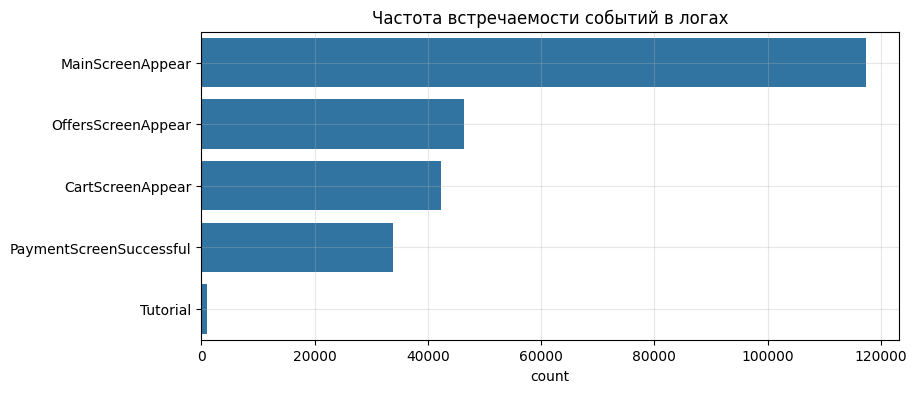

In [63]:
plt.figure(figsize=(9,4))

sns.barplot(data=events_freq, x ='count', y='event_name')

plt.title('Частота встречаемости событий в логах')
plt.ylabel('')
plt.grid(alpha=0.3)
plt.show()

Наиболее часто встречается событие MainScreenAppear, что ожидаемо, поскольку через главный экран проходит практически каждый пользователь. Далее частота событий постепенно снижается по мере продвижения пользователя к покупке.

#### Сколько пользователей совершали каждое из событий

In [64]:
events_df = logs.groupby('event_name', as_index=False)['user_id'].nunique()
events_df.columns = ['event_name', 'cnt_users']
events_df['users_share'] = round(events_df['cnt_users'] / logs['user_id'].nunique(), 2)
events_df = events_df.sort_values(by='cnt_users', ascending=False)
events_df

,event_name,cnt_users,users_share
1,MainScreenAppear,7419,0.98
2,OffersScreenAppear,4593,0.61
0,CartScreenAppear,3734,0.50
3,PaymentScreenSuccessful,3539,0.47
4,Tutorial,840,0.11


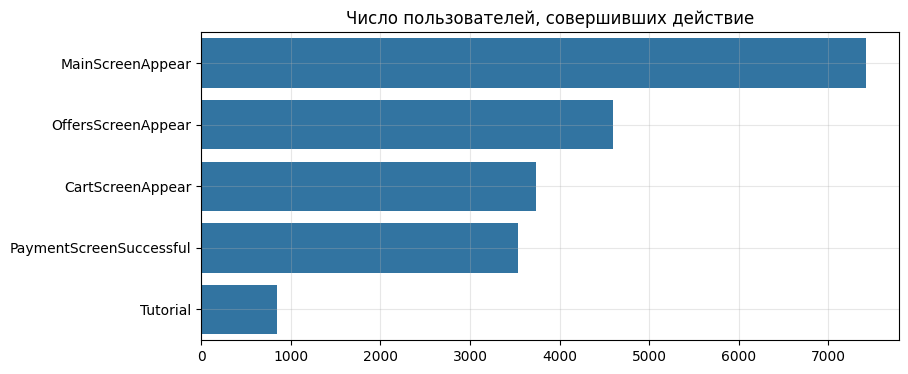

In [65]:
plt.figure(figsize=(9,4))
sns.barplot(data=events_df, x ='cnt_users', y='event_name')

plt.title('Число пользователей, совершивших действие')
plt.ylabel('')
plt.xlabel('')
plt.grid(alpha=0.3)
plt.show()

Главный экран посещают почти все пользователи приложения. На каждом следующем этапе число пользователей уменьшается, что свидетельствует о постепенном оттоке пользователей в процессе оформления заказа.

На основе названий событий можно восстановить предполагаемый путь пользователя:

Главный экран → Экран предложений → Корзина → Успешная оплата.

Событие Tutorial не является обязательным этапом покупки и может происходить независимо от основной пользовательской траектории. Поэтому оно исключается из анализа воронки.

In [66]:
events_df = events_df.query("event_name != 'Tutorial'")
logs = logs.query("event_name != 'Tutorial'")

#### Какая доля пользователей проходит на следующий шаг воронки

In [67]:
funnel_order = ['MainScreenAppear',
                'OffersScreenAppear',
                'CartScreenAppear',
                'PaymentScreenSuccessful']

events_df = events_df.set_index('event_name').loc[funnel_order].reset_index()

In [68]:
events_df['cnt_users_prev'] = events_df['cnt_users'].shift(1)

In [69]:
events_df['funnel'] = round(events_df['cnt_users'] / events_df['cnt_users_prev'], 2)
events_df

,event_name,cnt_users,users_share,cnt_users_prev,funnel
0,MainScreenAppear,7419,0.98,NaN,NaN
1,OffersScreenAppear,4593,0.61,7419.0,0.62
2,CartScreenAppear,3734,0.50,4593.0,0.81
3,PaymentScreenSuccessful,3539,0.47,3734.0,0.95


Наибольший отток пользователей наблюдается на этапе перехода с главного экрана к экрану предложений. До следующего шага доходит лишь около 62% пользователей. Таким образом, именно этот этап является основным узким местом воронки и требует дополнительного исследования.

In [70]:
print(f"С первого шага до оплаты доходит {events_df.loc[3, 'cnt_users'] / events_df.loc[1, 'cnt_users']:.1%} пользователей")

С первого шага до оплаты доходит 77.1% пользователей


От первого взаимодействия с приложением до успешной оплаты доходят около 48% пользователей. Для мобильного приложения это достаточно высокий показатель, однако почти половина пользователей всё же не завершает покупку.

# Анализ результатов A/A/B-теста

#### Сколько пользователей в каждой экспериментальной группе

In [71]:
total_users = logs.groupby('exp_id')['user_id'].nunique().to_frame()
total_users.columns = ['users_cnt']
total_users

,users_cnt
exp_id,
246,2483
247,2512
248,2535


Численность групп практически одинакова, что говорит о корректном распределении пользователей между экспериментальными выборками.

In [72]:
unique_246_users = logs.query('exp_id == "246"')['user_id'].unique()
unique_247_users = logs.query('exp_id == "247"')['user_id'].unique()
unique_248_users = logs.query('exp_id == "248"')['user_id'].unique()
intersect_users = list(set(unique_246_users) & set(unique_247_users) & set(unique_248_users))

print(f'Количество пользователей, которые попали в несколько групп сразу: {len(intersect_users)}')

Количество пользователей, которые попали в несколько групп сразу: 0


Пользователей, одновременно попавших в несколько групп, не обнаружено. Следовательно, разделение участников эксперимента выполнено корректно.

#### Находят ли статистические критерии разницу между 2 контрольными группами для А/А-эксперимента?

In [73]:
events_group_df = logs.pivot_table(index='exp_id', columns='event_name', values='user_id', aggfunc='nunique')
events_group_df = events_group_df.join(total_users)
events_group_df

,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,users_cnt
exp_id,,,,,
246,1266,2450,1542,1200,2483
247,1238,2476,1520,1158,2512
248,1230,2493,1531,1181,2535


In [74]:
events_group_df.loc['246+247'] = events_group_df.loc[[246, 247]].sum()
events_group_df

,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,users_cnt
exp_id,,,,,
246,1266,2450,1542,1200,2483
247,1238,2476,1520,1158,2512
248,1230,2493,1531,1181,2535
246+247,2504,4926,3062,2358,4995


In [75]:
def share_calc(name, col):
    return events_group_df[col] / events_group_df['users_cnt']

In [76]:
for name, col in {'CartScreenAppear_share': 'CartScreenAppear', 
                     'MainScreenAppear_share': 'MainScreenAppear', 
                     'OffersScreenAppear_share': 'OffersScreenAppear',
                     'PaymentScreenSuccessful_share': 'PaymentScreenSuccessful'
                    }.items():
    
    events_group_df[name] =  share_calc(name, col)   

In [77]:
events_group_df

,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,users_cnt,CartScreenAppear_share,MainScreenAppear_share,OffersScreenAppear_share,PaymentScreenSuccessful_share
exp_id,,,,,,,,,
246,1266,2450,1542,1200,2483,0.509867,0.986710,0.621023,0.483286
247,1238,2476,1520,1158,2512,0.492834,0.985669,0.605096,0.460987
248,1230,2493,1531,1181,2535,0.485207,0.983432,0.603945,0.465878
246+247,2504,4926,3062,2358,4995,0.501301,0.986186,0.613013,0.472072


In [78]:
def stat_z_test(group1, group2, event):

    alpha = 0.05 
    
    p1 = events_group_df.loc[group1, event+'_share']
    p2 = events_group_df.loc[group2, event+'_share']

    success_1 = events_group_df.loc[group1, event]
    success_2 = events_group_df.loc[group2, event]

    # размеры групп
    n1 = events_group_df.loc[group1, 'users_cnt']
    n2 = events_group_df.loc[group2, 'users_cnt']

    # пропорция успехов в комбинированном датасете
    p_combined = (success_1 + success_2) / (n1 + n2)

    # разница пропорций в датасетах
    difference = p1 - p2

    #считаем статистику в ст.отклонениях стандартного нормального распределения
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

    #задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
    distr = st.norm(0, 1)

    p_value = (1 - distr.cdf(abs(z_value))) * 2

    print(event)
    print('p-значение: ', p_value)

    if (p_value < alpha):
        print("Отвергаем нулевую гипотезу: между долями есть значимая разница")
    else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными")

In [79]:
for event in events_df['event_name'].unique():
    stat_z_test(246, 247, event)
    print()

MainScreenAppear
p-значение:  0.7526703436483038
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

OffersScreenAppear
p-значение:  0.24786096925282264
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

CartScreenAppear
p-значение:  0.22867643757335676
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

PaymentScreenSuccessful
p-значение:  0.11446627829276612
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными



Для всех исследуемых событий различия между контрольными группами 246 и 247 статистически незначимы (p-value превышают уровень значимости 0.05). Это свидетельствует о корректной работе механизма разбиения пользователей на группы и позволяет использовать результаты эксперимента для дальнейшего анализа.

#### Анализ влияния нового шрифта на поведение пользователей

In [80]:
for event in events_df['event_name'].unique():
    stat_z_test(246, 248, event)
    print()

MainScreenAppear
p-значение:  0.3387114076159288
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

OffersScreenAppear
p-значение:  0.21442476639710506
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

CartScreenAppear
p-значение:  0.08067367598823139
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

PaymentScreenSuccessful
p-значение:  0.21693033984516674
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными



In [81]:
for event in events_df['event_name'].unique():
    stat_z_test(247, 248, event)
    print()

MainScreenAppear
p-значение:  0.5194964354051703
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

OffersScreenAppear
p-значение:  0.9333751305879443
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

CartScreenAppear
p-значение:  0.5878284605111943
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

PaymentScreenSuccessful
p-значение:  0.7275718682261119
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными



In [82]:
for event in events_df['event_name'].unique():
    stat_z_test('246+247', 248, event)
    print()

MainScreenAppear
p-значение:  0.3486684291093256
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

OffersScreenAppear
p-значение:  0.44582745409482394
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

CartScreenAppear
p-значение:  0.18683558686831558
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

PaymentScreenSuccessful
p-значение:  0.6107918742187335
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными



Для всех исследуемых событий статистически значимых различий между контрольной группой 246 и экспериментальной группой 248 обнаружено не было.

Аналогично для 247 и 248.

После объединения контрольных групп и сравнения с экспериментальной группой статистически значимые различия также отсутствуют. Следовательно, изменение шрифта не оказало заметного влияния на поведение пользователей.

#### Поправки на множественные проверки

В рамках исследования было проведено 16 статистических проверок:

- 4 сравнения между группами 246 и 247;
- 4 сравнения между группами 246 и 248;
- 4 сравнения между группами 247 и 248;
- 4 сравнения между объединённой контрольной группой и группой 248.

При множественных проверках возрастает вероятность ошибки первого рода, поэтому можно применить поправку Бонферрони. В этом случае скорректированный уровень значимости составит 0.05 / 16 = 0.003125.

Даже после применения более строгого уровня значимости результаты не изменились. Оснований отвергать нулевые гипотезы не возникает, что дополнительно подтверждает отсутствие эффекта от изменения шрифта.

# Выводы

В ходе исследования были проанализированы данные о действиях пользователей мобильного приложения продуктового магазина и результаты A/A/B-теста.

После изучения распределения событий по времени было выявлено, что полноценные данные начинают собираться с 1 августа 2019 года. Более ранние записи были исключены из анализа как неполные. При этом потери пользователей и событий оказались незначительными и не повлияли на результаты исследования.

Анализ пользовательской воронки показал, что основной путь пользователя состоит из следующих этапов: главный экран → экран предложений → корзина → успешная оплата. Наибольшие потери происходят при переходе с главного экрана на экран предложений: до следующего шага доходит около 62% пользователей. До успешной оплаты доходят примерно 48% пользователей, начавших взаимодействие с приложением.

Для проверки корректности эксперимента были сначала сравнены две контрольные группы. Статистически значимых различий между группами 246 и 247 не обнаружено ни по одному из событий, что подтверждает корректность механизма разбиения пользователей.

Далее была выполнена проверка различий между экспериментальной группой 248 и контрольными группами по всем ключевым событиям. Во всех случаях p-value превышало выбранный уровень значимости 0.05, поэтому оснований отвергнуть нулевую гипотезу не получено.

Эксперимент не выявил статистически значимого влияния нового шрифта на пользовательское поведение. На основании проведённого исследования отсутствуют причины отказываться от внедрения нового дизайна. Решение о смене шрифта может приниматься исходя из дизайнерских и продуктовых соображений, поскольку негативного влияния на ключевые пользовательские метрики не обнаружено.
